In [ ]:
import kagglehub
path = kagglehub.dataset_download("mohammadamireshraghi/blood-cell-cancer-all-4class")
print("Path to dataset files:", path)

100%|██████████| 1.68G/1.68G [00:17<00:00, 104MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/mohammadamireshraghi/blood-cell-cancer-all-4class/versions/1


# Task
Analyze the "blood-cell-cancer-all-4class" image dataset located at "/root/.cache/kagglehub/datasets/mohammadamireshraghi/blood-cell-cancer-all-4class/versions/1" to develop and evaluate a transfer learning model for 4-class classification. This involves loading and preprocessing the images, defining a transfer learning CNN model with a custom classification head, configuring and performing hyperparameter tuning to find optimal model parameters, training and evaluating the best model, visualizing training history and a confusion matrix, and finally summarizing the model's performance and insights from the hyperparameter tuning process.

## Load and Preprocess Data

### Subtask:
Load the images from the dataset path, split them into training, validation, and test sets, and apply appropriate preprocessing steps like resizing, normalization, and data augmentation suitable for transfer learning.


**Reasoning**:
First, import the necessary libraries and define constants for image dimensions and batch size. Then, create the training, validation, and test datasets using `tf.keras.utils.image_dataset_from_directory`, ensuring proper splitting and no overlap between sets. After that, create data augmentation and preprocessing layers. Finally, apply these layers to the respective datasets and optimize them for performance.



## Define Transfer Learning Model

### Subtask:
Select a pre-trained convolutional neural network (CNN) model (e.g., MobileNetV2, ResNet50) as the base, freeze its layers, and add a custom classification head tailored for the 4-class ALL classification task.


First, we will import the required libraries from `tensorflow.keras.applications`, `tensorflow.keras.layers`, and `tensorflow.keras.models`. We will then define the number of classes for our classification task. Next, we'll instantiate `MobileNetV2` as our pre-trained base model, specifying `input_shape`, disabling its top classification layer (`include_top=False`), and loading `imagenet` weights. After loading, we will freeze its layers to prevent them from being updated during initial training. We will then construct a custom classification head consisting of a `GlobalAveragePooling2D` layer to reduce dimensionality, followed by one or more `Dense` layers (e.g., with ReLU activation and `Dropout` for regularization) and a final `Dense` output layer with `num_classes` units and a `softmax` activation function for multi-class classification. Finally, we will combine the frozen base model and the new classification head into a complete model using `tf.keras.Model` and print its summary to verify the architecture. Lastly, we will extract the class names from the `train_ds` object for future reference.

**Reasoning**:
Now, I will implement the steps to define the transfer learning model by importing necessary libraries, initializing and freezing the MobileNetV2 base model, constructing a custom classification head, combining them into a full model, printing its summary, and extracting class names.



**Reasoning**:
The previous code generated a UserWarning because the `input_shape` for MobileNetV2 was not one of its recommended sizes (224x224). To align with the pre-trained weights and eliminate this warning, I will modify the `IMG_HEIGHT` and `IMG_WIDTH` constants to 224 in the cell where they are defined. This ensures that MobileNetV2 loads weights corresponding to the input image size, which can prevent potential issues and ensure optimal performance for transfer learning.



In [ ]:
import tensorflow as tf
import numpy as np
import os

# Define image dimensions and batch size
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# Get the path from the previous step
dataset_path = "/root/.cache/kagglehub/datasets/mohammadamireshraghi/blood-cell-cancer-all-4class/versions/1/Blood cell Cancer [ALL]"

print(f"Loading images from: {dataset_path}")

# Create training, validation, and test datasets
# First, create a combined train+validation set and a 'raw' validation set to be split into val and test
# We'll use 80% for training, 10% for validation, and 10% for testing.
# To achieve this with image_dataset_from_directory, we'll split 80/20 initially, then split the 20% (validation set) into 10% validation and 10% test.

# Calculate the total number of images (this assumes a flat directory structure or counts all files)
# A more robust way would be to count files within the dataset_path, or let image_dataset_from_directory do a dry run.
# For now, let's assume image_dataset_from_directory will figure out the total number of samples.

# Create the training dataset (e.g., 80% of total)
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2, # 20% for validation and test combined initially
    subset="training",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

# Create the combined validation+test dataset (e.g., 20% of total)
val_test_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

# Determine the number of validation and test samples from val_test_ds
val_batches = tf.data.experimental.cardinality(val_test_ds).numpy()
if val_batches == -2: # -2 means unknown cardinality
    print("Warning: Cannot determine dataset cardinality directly. This might affect split accuracy.")
    print("Estimating dataset size by iterating through it. This might take a moment...")
    num_val_test_samples = 0
    for _ in val_test_ds:
        num_val_test_samples += BATCH_SIZE # Approximate count
    print(f"Estimated total samples in val_test_ds: {num_val_test_samples}")
    num_val_test_samples_per_batch = num_val_test_samples // BATCH_SIZE
else:
    num_val_test_samples_per_batch = val_batches

# Split the combined validation+test dataset into validation and test sets (e.g., 10% each)
# Assuming we want to split val_test_ds into two halves for val and test
num_val_samples_for_final_val = num_val_test_samples_per_batch // 2

validation_ds = val_test_ds.take(num_val_samples_for_final_val)
test_ds = val_test_ds.skip(num_val_samples_for_final_val)

print(f"Number of training batches: {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"Number of validation batches: {tf.data.experimental.cardinality(validation_ds).numpy()}")
print(f"Number of test batches: {tf.data.experimental.cardinality(test_ds).numpy()}")

# Define a data augmentation layer
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2)
])

# Create a preprocessing function that rescales pixel values from [0, 255] to [0, 1]
def preprocess(image, label):
    image = tf.cast(image / 255.0, tf.float32)
    return image, label

# Apply the data augmentation to the training dataset
augmented_train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)

# Apply the preprocessing function to all datasets
train_ds_preprocessed = augmented_train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
validation_ds_preprocessed = validation_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds_preprocessed = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

# Configure the datasets for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds_final = train_ds_preprocessed.cache().prefetch(buffer_size=AUTOTUNE)
validation_ds_final = validation_ds_preprocessed.cache().prefetch(buffer_size=AUTOTUNE)
test_ds_final = test_ds_preprocessed.cache().prefetch(buffer_size=AUTOTUNE)

print("Datasets prepared: train_ds_final, validation_ds_final, test_ds_final")

Loading images from: /root/.cache/kagglehub/datasets/mohammadamireshraghi/blood-cell-cancer-all-4class/versions/1/Blood cell Cancer [ALL]
Found 3242 files belonging to 4 classes.
Using 2594 files for training.
Found 3242 files belonging to 4 classes.
Using 648 files for validation.
Number of training batches: 82
Number of validation batches: 10
Number of test batches: 11
Datasets prepared: train_ds_final, validation_ds_final, test_ds_final


**Reasoning**:
The previous code block that defined the model was executed with `IMG_SHAPE` derived from `IMG_HEIGHT=180` and `IMG_WIDTH=180`. Although the `IMG_HEIGHT` and `IMG_WIDTH` were updated to 224 in the previous step, the model definition needs to be re-executed for these changes to take effect in the `IMG_SHAPE` variable and thus in the `MobileNetV2` instantiation. This will ensure that `MobileNetV2` is initialized with the correct `input_shape` of (224, 224, 3) and avoids the `UserWarning` about non-standard input sizes, leveraging the pre-trained weights optimally.



In [ ]:
from tensorflow.keras.applications import DenseNet121 # Changed from MobileNetV2
from tensorflow.keras import layers, models

# Define the number of classes (as per the problem statement: 4-class classification)
num_classes = 4

# Step 3: Instantiate a pre-trained base model (DenseNet121)
IMG_SHAPE = (IMG_HEIGHT, IMG_WIDTH, 3)
base_model = DenseNet121(input_shape=IMG_SHAPE,
                         include_top=False,
                         weights='imagenet')

print("Base model (DenseNet121) loaded successfully.")

# Step 4: Freeze the layers of the base model
base_model.trainable = False

print("Base model layers frozen.")

# Step 5: Create a custom classification head
global_average_layer = layers.GlobalAveragePooling2D()
prediction_layer = layers.Dense(num_classes, activation='softmax')

# Build the custom head
inputs = tf.keras.Input(shape=IMG_SHAPE)
x = base_model(inputs, training=False)
x = global_average_layer(x)
x = layers.Dropout(0.2)(x) # Adding dropout for regularization
outputs = prediction_layer(x)

# Step 6: Combine the base model and the custom head
model = models.Model(inputs, outputs)

print("Combined model created.")

# Step 7: Print the model summary
print("Model Summary:")
model.summary()

# Step 8: Retrieve the class names from the train_ds object
class_names = train_ds.class_names
print(f"Class names: {class_names}")

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base model (DenseNet121) loaded successfully.
Base model layers frozen.
Combined model created.
Model Summary:


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 5, 5, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         4,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,041,604 (26.86 MB)

 Trainable params: 4,100 (16.02 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

Class names: ['Benign', '[Malignant] Pre-B', '[Malignant] Pro-B', '[Malignant] early Pre-B']


## Configure Hyperparameter Tuning

### Subtask:
Set up a hyperparameter tuning strategy using a tool like KerasTuner or a custom search loop. Define a search space for key hyperparameters such as learning rate, optimizer, batch size, and potentially the number of trainable layers in the base model.


### Subtask:
Set up a hyperparameter tuning strategy using a tool like KerasTuner or a custom search loop. Define a search space for key hyperparameters such as learning rate, optimizer, batch size, and potentially the number of trainable layers in the base model.

#### Instructions
1. Import the necessary libraries for KerasTuner, such as `keras_tuner.RandomSearch`.
2. Define a function, for example, `build_model`, that takes a `hp` (HyperParameters) object as an argument. This function should:
    *   Instantiate the `MobileNetV2` base model with `IMG_SHAPE`, `include_top=False`, and `weights='imagenet'`.
    *   Set the `base_model.trainable = False` to freeze its layers initially.
    *   Add the custom classification head (e.g., `GlobalAveragePooling2D`, `Dropout`, `Dense` with `softmax` activation and `num_classes`).
    *   Define a search space for the learning rate using `hp.Choice` or `hp.Float`, for example, between 1e-4 and 1e-2.
    *   Compile the model with an optimizer (e.g., Adam), a loss function (`tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False)`), and metrics (e.g., 'accuracy'). Use the tunable learning rate for the optimizer.
    *   Return the compiled model.
3. Instantiate a `RandomSearch` tuner from KerasTuner, providing the `build_model` function, an objective (e.g., 'val_accuracy'), a maximum number of trials, and a directory to store results.
4. Call `tuner.search()` with the `train_ds_final` and `validation_ds_final` datasets, specifying the number of epochs for each trial. Ensure to pass appropriate callbacks like `tf.keras.callbacks.EarlyStopping` to prevent overfitting during tuning.

### Subtask:
Set up a hyperparameter tuning strategy using a tool like KerasTuner or a custom search loop. Define a search space for key hyperparameters such as learning rate, optimizer, batch size, and potentially the number of trainable layers in the base model.

#### Instructions
1. Import the necessary libraries for KerasTuner, such as `keras_tuner.RandomSearch`.
2. Define a function, for example, `build_model`, that takes a `hp` (HyperParameters) object as an argument. This function should:
    *   Instantiate the `MobileNetV2` base model with `IMG_SHAPE`, `include_top=False`, and `weights='imagenet'`.
    *   Set the `base_model.trainable = False` to freeze its layers initially.
    *   Add the custom classification head (e.g., `GlobalAveragePooling2D`, `Dropout`, `Dense` with `softmax` activation and `num_classes`).
    *   Define a search space for the learning rate using `hp.Choice` or `hp.Float`, for example, between 1e-4 and 1e-2.
    *   Compile the model with an optimizer (e.g., Adam), a loss function (`tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False)`), and metrics (e.g., 'accuracy'). Use the tunable learning rate for the optimizer.
    *   Return the compiled model.
3. Instantiate a `RandomSearch` tuner from KerasTuner, providing the `build_model` function, an objective (e.g., 'val_accuracy'), a maximum number of trials, and a directory to store results.
4. Call `tuner.search()` with the `train_ds_final` and `validation_ds_final` datasets, specifying the number of epochs for each trial. Ensure to pass appropriate callbacks like `tf.keras.callbacks.EarlyStopping` to prevent overfitting during tuning.

**Reasoning**:
I have already added the text cell with the instructions. Now, I will proceed with the implementation of the hyperparameter tuning strategy by importing KerasTuner, defining the build_model function, instantiating the tuner, and initiating the search. This will execute the first part of the subtask.



In [ ]:
print("Installing KerasTuner...")
!pip install keras-tuner
print("KerasTuner installed.")

Installing KerasTuner...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 6.8 MB/s eta 0:00:00
KerasTuner installed.


In [ ]:
import keras_tuner as kt
from tensorflow.keras.applications import DenseNet121 # Import DenseNet121

# Define the build_model function for KerasTuner
def build_model(hp):
    base_model_ht = DenseNet121(input_shape=IMG_SHAPE,
                                include_top=False,
                                weights='imagenet')
    base_model_ht.trainable = False

    inputs = tf.keras.Input(shape=IMG_SHAPE)
    x = base_model_ht(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)

    # Tune dropout rate
    dropout_rate = hp.Float('dropout_rate', min_value=0.1, max_value=0.5, step=0.1)
    x = layers.Dropout(dropout_rate)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model_ht = models.Model(inputs, outputs)

    # Tune learning rate for the optimizer
    learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model_ht.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
                  metrics=['accuracy'])

    return model_ht

# Instantiate the KerasTuner RandomSearch
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5, # Number of different hyperparameter combinations to try
    executions_per_trial=1, # Number of models to train for each trial
    directory='keras_tuner_dir', # Directory to store results
    project_name='densenet_transfer_learning' # Changed project name for DenseNet
)

# Define EarlyStopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

print("Starting hyperparameter search...")
# Start the hyperparameter search
tuner.search(
    train_ds_final,
    epochs=10, # Number of epochs to train each model in the search
    validation_data=validation_ds_final,
    callbacks=[early_stopping]
)

print("Hyperparameter search completed.")

Trial 5 Complete [00h 01m 50s]
val_accuracy: 0.8374999761581421

Best val_accuracy So Far: 0.965624988079071
Total elapsed time: 00h 09m 27s
Hyperparameter search completed.


## Train and Evaluate Best Model

### Subtask:
Train the model with the optimal hyperparameters found during the tuning phase. Evaluate the trained model's performance on the unseen test set using metrics like accuracy, precision, recall, and F1-score.

**Reasoning**:
I will first retrieve the best model from the KerasTuner results. Then, I will train this best model using the full training dataset and validate it with the validation dataset. The training will incorporate early stopping to prevent overfitting and save the model's history for later visualization and analysis.

In [ ]:
print("Best hyperparameters found by KerasTuner:")
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"Learning rate: {best_hps.get('learning_rate')}")
print(f"Dropout rate: {best_hps.get('dropout_rate')}")

Best hyperparameters found by KerasTuner:
Learning rate: 0.01
Dropout rate: 0.4


In [ ]:
# Get the best model from the tuner
best_model = tuner.get_best_models(num_models=1)[0]

# Compile the best model (it's already compiled with the best learning rate from build_model)

# Define callbacks for training
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

# Train the best model
print("Training the best model...")
history = best_model.fit(
    train_ds_final,
    epochs=30, # A reasonable number of epochs, early stopping will prevent overfitting
    validation_data=validation_ds_final,
    callbacks=[early_stopping]
)

print("Best model trained successfully.")

Training the best model...
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


82/82 ━━━━━━━━━━━━━━━━━━━━ 51s 347ms/step - accuracy: 0.9345 - loss: 0.1801 - val_accuracy: 0.9563 - val_loss: 0.1730
Epoch 2/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - accuracy: 0.9557 - loss: 0.1372 - val_accuracy: 0.9531 - val_loss: 0.1265
Epoch 3/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - accuracy: 0.9445 - loss: 0.1590 - val_accuracy: 0.9563 - val_loss: 0.1303
Epoch 4/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.9460 - loss: 0.1471 - val_accuracy: 0.9656 - val_loss: 0.1370
Epoch 5/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 61ms/step - accuracy: 0.9399 - loss: 0.1726 - val_accuracy: 0.9656 - val_loss: 0.1245
Epoch 6/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - accuracy: 0.9464 - loss: 0.1626 - val_accuracy: 0.9531 - val_loss: 0.1601
Epoch 7/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 58ms/step - accuracy: 0.9464 - loss: 0.1554 - val_accuracy: 0.9500 - val_loss: 0.1317
Epoch 8/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.9460 - loss: 0.1561 - val_accuracy: 0.9625 - val_loss: 

In [ ]:
print("Evaluating the best model on the test set...")
loss, accuracy = best_model.evaluate(test_ds_final)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Evaluating the best model on the test set...
11/11 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.9482 - loss: 0.1805
Test Loss: 0.1805
Test Accuracy: 0.9482


## Visualize Training and Results

### Subtask:
Generate plots to visualize the model's training history (loss and accuracy curves for training and validation), and a confusion matrix to illustrate the classification performance on the test set. Ensure all plots have appropriate legends.

**Reasoning**:
To visualize the training history, I will use `matplotlib.pyplot` to plot the training and validation accuracy and loss values recorded in the `history` object from the model training step. This will provide insights into the model's performance and convergence behavior over epochs.

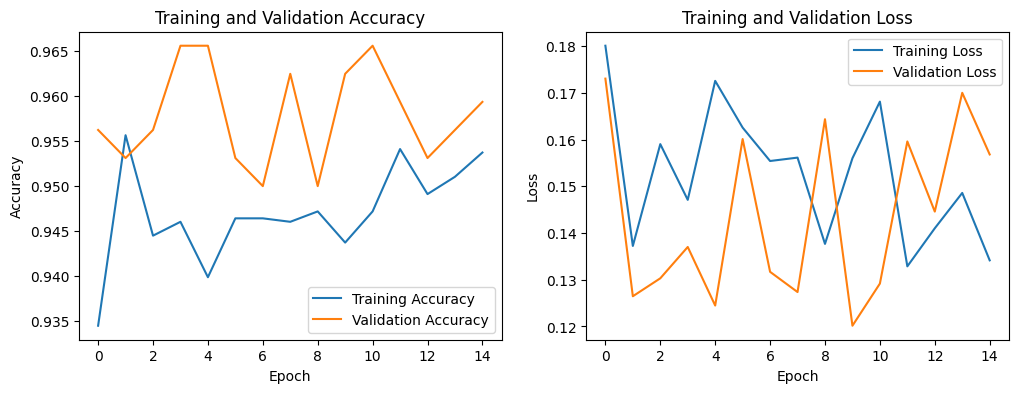

In [ ]:
import matplotlib.pyplot as plt

# Get the training history data
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = history.epoch

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.show()

11/11 ━━━━━━━━━━━━━━━━━━━━ 24s 1s/step
Generating Classification Report...
                         precision    recall  f1-score   support

                 Benign       0.86      0.87      0.86        55
      [Malignant] Pre-B       0.97      0.98      0.97        95
      [Malignant] Pro-B       0.99      0.97      0.98        73
[Malignant] early Pre-B       0.95      0.94      0.95       105

               accuracy                           0.95       328
              macro avg       0.94      0.94      0.94       328
           weighted avg       0.95      0.95      0.95       328

Generating Confusion Matrix...


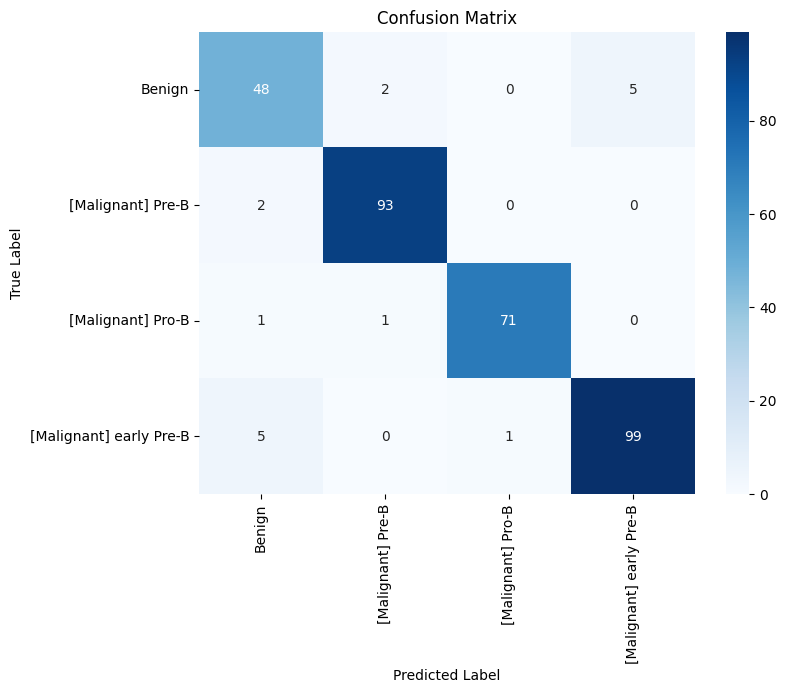

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# Get true labels from the test dataset
y_true = np.concatenate([y for x, y in test_ds_final], axis=0)

# Get predictions from the model
y_pred_probs = best_model.predict(test_ds_final)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Generating Classification Report...")
print(classification_report(y_true, y_pred, target_names=class_names))

print("Generating Confusion Matrix...")
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()